# Part 5: Guardrail Pipeline

**Objective:** Demonstrate the `ModerationPipeline` class on 1,000 evaluation examples and analyse its three-layer decision distribution.

**Architecture:**
```
Input text
    │
    ▼
Layer 1: Regex Pre-filter ──── match ──► BLOCK (category-labelled, instant)
    │ no match
    ▼
Layer 2: Calibrated DistilBERT
    ├── confidence ≥ 0.6 ──────────────► BLOCK
    ├── confidence ≤ 0.4 ──────────────► ALLOW
    └── 0.4 < confidence < 0.6 ────────► REVIEW (Layer 3)
```

In [ ]:
!pip install -q transformers==4.40.0 scikit-learn==1.4.2 fairlearn==0.10.0 \
             aif360==0.6.1 matplotlib seaborn pandas numpy torch --quiet

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

DATA_DIR        = '/content/drive/MyDrive'
CHECKPOINT_DIR  = '/content/drive/MyDrive/jigsaw_checkpoints'
BEST_MITIGATED  = os.path.join(CHECKPOINT_DIR, 'best_mitigated_model')
SEED = 42
np.random.seed(SEED)

# ── Upload pipeline.py to Colab and import ─────────────────────────────────
# Option A: upload via the Files panel (left sidebar → upload)
# Option B: copy from Drive:
#   !cp "/content/drive/MyDrive/jigsaw_data/pipeline.py" /content/pipeline.py
# Then:
sys.path.insert(0, '/content/pipeline.py')
from pipeline import ModerationPipeline, input_filter, BLOCKLIST

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


## Step 1: Initialise the Pipeline

We use the best mitigated model from Part 4 and fit an isotonic calibrator on a representative calibration subset.

In [4]:
df_eval = pd.read_csv(os.path.join(DATA_DIR, 'eval_subset.csv'))

# Use a 2,000-row calibration subset (separate from the 1,000-row demo set)
df_calib = df_eval.sample(2000, random_state=SEED).reset_index(drop=True)
remaining = df_eval.drop(df_calib.index).reset_index(drop=True)
df_demo   = remaining.sample(1000, random_state=SEED).reset_index(drop=True)

print(f'Calibration set : {len(df_calib):,}')
print(f'Demo set        : {len(df_demo):,}')
print(f'Demo toxic rate : {df_demo["label"].mean():.4f}')

print('\nInitialising ModerationPipeline…')
pipeline = ModerationPipeline(
    model_path=BEST_MITIGATED,
    block_threshold=0.6,
    allow_threshold=0.4,
    calibration_texts=df_calib['comment_text'].tolist(),
    calibration_labels=df_calib['label'].tolist(),
    device=DEVICE
)
print('Pipeline ready.')

Calibration set : 2,000
Demo set        : 1,000
Demo toxic rate : 0.0740

Initialising ModerationPipeline…


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Getting raw probabilities for calibration set…
Isotonic calibrator fitted.
Pipeline ready.


## Step 2: Run Layer 1 on All 1,000 Demo Comments

Count how many were blocked by each regex category.

Layer 1 triggered on: 25 / 1000 comments (2.5%)

Breakdown by category:
  direct_threat                 :  23 comments
  dehumanization                :   2 comments


/tmp/ipykernel_630/2109885343.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=20, ha='right')


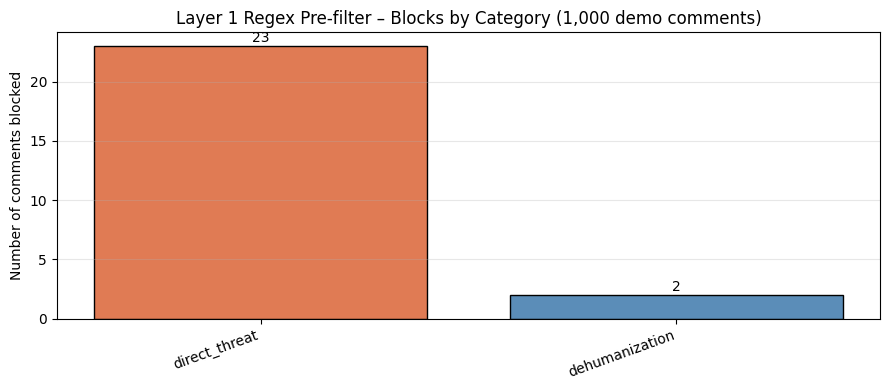

In [5]:
from collections import Counter

layer1_results = [input_filter(t) for t in df_demo['comment_text']]
layer1_hits    = [r for r in layer1_results if r is not None]
category_counts = Counter(r['category'] for r in layer1_hits)

print(f'Layer 1 triggered on: {len(layer1_hits)} / {len(df_demo)} comments ({len(layer1_hits)/len(df_demo):.1%})')
print('\nBreakdown by category:')
for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat:30s}: {count:3d} comments')

# Bar chart
if category_counts:
    cats  = list(category_counts.keys())
    cnts  = [category_counts[c] for c in cats]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(cats, cnts, color=['#E07B54','#5B8DB8','#6BAF92','#C97BB2','#E8C662'],
                  edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', fontsize=10)
    ax.set_title('Layer 1 Regex Pre-filter – Blocks by Category (1,000 demo comments)')
    ax.set_ylabel('Number of comments blocked')
    ax.set_xticklabels(cats, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('No Layer 1 matches in this sample (normal for a clean evaluation set).')

## Step 3: Run Full Pipeline on All 1,000 Comments

In [6]:
print('Running pipeline on 1,000 comments (batch inference)…')
pipeline_results = pipeline.predict_batch(
    df_demo['comment_text'].tolist(),
    batch_size=64
)

df_demo['pipeline_decision']   = [r['decision']   for r in pipeline_results]
df_demo['pipeline_layer']      = [r['layer']       for r in pipeline_results]
df_demo['pipeline_confidence'] = [r['confidence']  for r in pipeline_results]

print('Done.')
print('\nDecision distribution:')
print(df_demo['pipeline_decision'].value_counts())

Running pipeline on 1,000 comments (batch inference)…
Done.

Decision distribution:
pipeline_decision
allow     897
block      91
review     12
Name: count, dtype: int64


## Step 4: Layer Distribution – Pie Chart

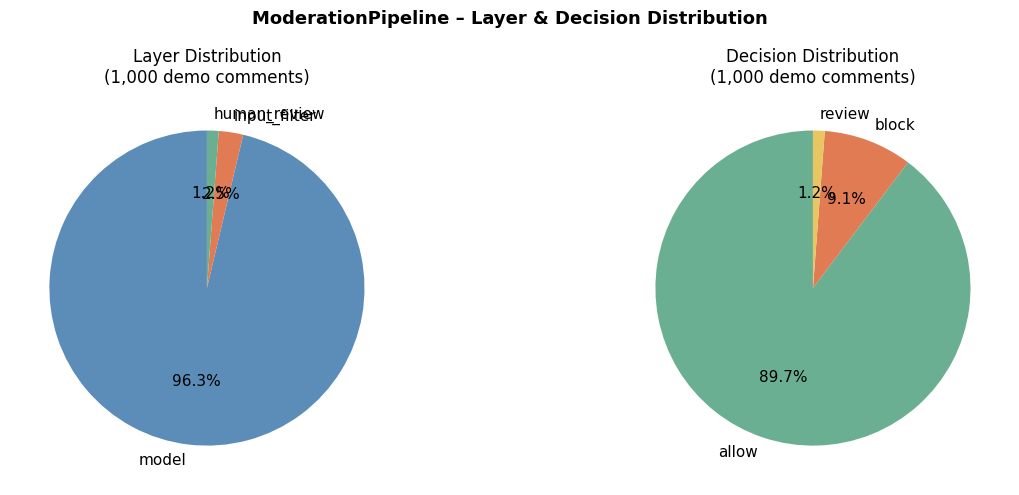

Layer breakdown:
  model               :  963 (96.3%)
  input_filter        :   25 (2.5%)
  human_review        :   12 (1.2%)


In [7]:
layer_counts  = df_demo['pipeline_layer'].value_counts()
decision_counts = df_demo['pipeline_decision'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Layer distribution
layer_labels = layer_counts.index.tolist()
layer_sizes  = layer_counts.values
axes[0].pie(layer_sizes, labels=layer_labels, autopct='%1.1f%%',
            colors=['#5B8DB8','#E07B54','#6BAF92'],
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Layer Distribution\n(1,000 demo comments)')

# Decision distribution
decision_labels = decision_counts.index.tolist()
decision_sizes  = decision_counts.values
color_map = {'block': '#E07B54', 'allow': '#6BAF92', 'review': '#E8C662'}
colors = [color_map.get(l, 'grey') for l in decision_labels]
axes[1].pie(decision_sizes, labels=decision_labels, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Decision Distribution\n(1,000 demo comments)')

plt.suptitle('ModerationPipeline – Layer & Decision Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Layer breakdown:')
for layer, count in layer_counts.items():
    print(f'  {layer:20s}: {count:4d} ({count/len(df_demo):.1%})')

## Step 5: Auto-Actioned Subset – F1, Precision, Recall

In [8]:
# Auto-actioned = Layer 2 confident decisions only (block or allow via model, NOT review queue)
auto_mask = (df_demo['pipeline_layer'] == 'model')  # Layer 1 + Layer 2 confident
# Actually include Layer 1 blocks too (they are auto-actioned)
auto_mask = df_demo['pipeline_decision'].isin(['block','allow']) & \
            (df_demo['pipeline_layer'] != 'human_review')

df_auto = df_demo[auto_mask].copy()
y_true_auto = df_auto['label'].values
y_pred_auto = (df_auto['pipeline_decision'] == 'block').astype(int).values

f1_auto   = f1_score(y_true_auto, y_pred_auto, average='macro', zero_division=0)
prec_auto = precision_score(y_true_auto, y_pred_auto, zero_division=0)
rec_auto  = recall_score(y_true_auto, y_pred_auto, zero_division=0)

print('=== Auto-Actioned Subset (Layer 1 blocks + Layer 2 confident decisions) ===')
print(f'  N comments  : {len(df_auto):,}')
print(f'  N toxic (GT): {y_true_auto.sum():,}')
print(f'  F1 (macro)  : {f1_auto:.4f}')
print(f'  Precision   : {prec_auto:.4f}')
print(f'  Recall      : {rec_auto:.4f}')

=== Auto-Actioned Subset (Layer 1 blocks + Layer 2 confident decisions) ===
  N comments  : 988
  N toxic (GT): 67
  F1 (macro)  : 0.7455
  Precision   : 0.4615
  Recall      : 0.6269


## Step 6: Review Queue – Actual Breakdown

=== Human Review Queue ===
  N comments sent to review: 12 (1.2%)
  Of these – actually toxic : 7 (58.3%)
  Of these – non-toxic      : 5 (41.7%)

Interpretation:
  Human reviewers will find ~58% of the review queue is genuinely toxic.
  This is the queue ambiguity rate — higher = more reviewer effort needed.


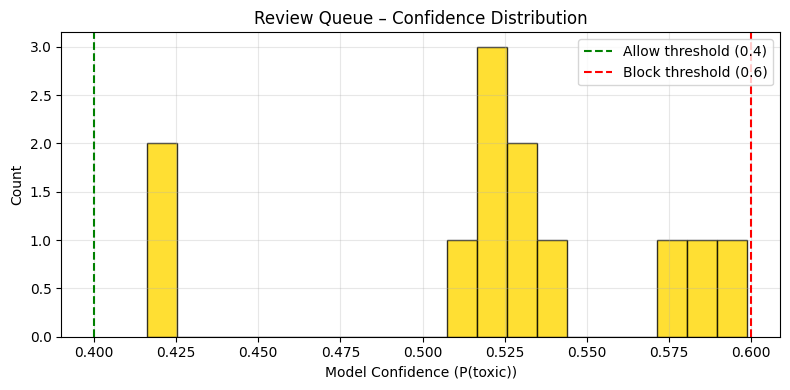

In [9]:
df_review = df_demo[df_demo['pipeline_decision'] == 'review'].copy()
review_toxic_rate = df_review['label'].mean() if len(df_review) > 0 else float('nan')

print('=== Human Review Queue ===')
print(f'  N comments sent to review: {len(df_review):,} ({len(df_review)/len(df_demo):.1%})')
print(f'  Of these – actually toxic : {df_review["label"].sum():,} ({review_toxic_rate:.1%})')
print(f'  Of these – non-toxic      : {(df_review["label"]==0).sum():,} ({1-review_toxic_rate:.1%})')
print()
print('Interpretation:')
print(f'  Human reviewers will find ~{review_toxic_rate:.0%} of the review queue is genuinely toxic.')
print(f'  This is the queue ambiguity rate — higher = more reviewer effort needed.')

# Confidence distribution for review queue
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_review['pipeline_confidence'], bins=20, color='gold', edgecolor='black', alpha=0.8)
ax.axvline(0.4, color='green', linestyle='--', label='Allow threshold (0.4)')
ax.axvline(0.6, color='red',   linestyle='--', label='Block threshold (0.6)')
ax.set_xlabel('Model Confidence (P(toxic))')
ax.set_ylabel('Count')
ax.set_title('Review Queue – Confidence Distribution')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 7: Threshold Sensitivity Analysis

We compare the default uncertainty band (0.4–0.6) against narrower (0.45–0.55) and wider (0.3–0.7) alternatives, measuring:
- Volume of human reviews
- Auto-action F1 (accuracy)
- Review queue toxic rate (ambiguity)

In [10]:
# We already have pipeline_confidence for all 1000 rows
# Re-evaluate at different band widths without re-running model inference

def evaluate_band(df, low, high, label):
    conf = df['pipeline_confidence'].values
    true = df['label'].values

    # Reassign decisions based on new thresholds
    decisions = np.where(conf >= high, 'block',
                np.where(conf <= low, 'allow', 'review'))

    n_review  = (decisions == 'review').sum()
    n_auto    = (decisions != 'review').sum()

    # Review queue
    rev_mask  = decisions == 'review'
    rev_toxic = true[rev_mask].mean() if rev_mask.sum() > 0 else float('nan')

    # Auto-action accuracy
    auto_mask = ~rev_mask
    if auto_mask.sum() > 0:
        y_true_a = true[auto_mask]
        y_pred_a = (decisions[auto_mask] == 'block').astype(int)
        f1_a     = f1_score(y_true_a, y_pred_a, average='macro', zero_division=0)
    else:
        f1_a = float('nan')

    return {
        'Band'              : label,
        'Allow < / Block ≥' : f'{low} / {high}',
        'N Review'          : n_review,
        'Review %'          : f'{n_review/len(df):.1%}',
        'Review Toxic Rate' : f'{rev_toxic:.3f}' if not np.isnan(rev_toxic) else 'N/A',
        'Auto-Action F1'    : f'{f1_a:.4f}' if not np.isnan(f1_a) else 'N/A',
    }

bands = [
    (0.3, 0.7, 'Wide   (0.3–0.7)'),
    (0.4, 0.6, 'Default (0.4–0.6)'),
    (0.45, 0.55, 'Narrow (0.45–0.55)'),
]

band_results = [evaluate_band(df_demo, low, high, label) for low, high, label in bands]
band_df = pd.DataFrame(band_results)
print('=== Threshold Sensitivity Analysis ===')
print(band_df.to_string(index=False))

=== Threshold Sensitivity Analysis ===
              Band Allow < / Block ≥  N Review Review % Review Toxic Rate Auto-Action F1
  Wide   (0.3–0.7)         0.3 / 0.7        23     2.3%             0.522         0.7441
 Default (0.4–0.6)         0.4 / 0.6        12     1.2%             0.583         0.7455
Narrow (0.45–0.55)       0.45 / 0.55         7     0.7%             0.429         0.7455


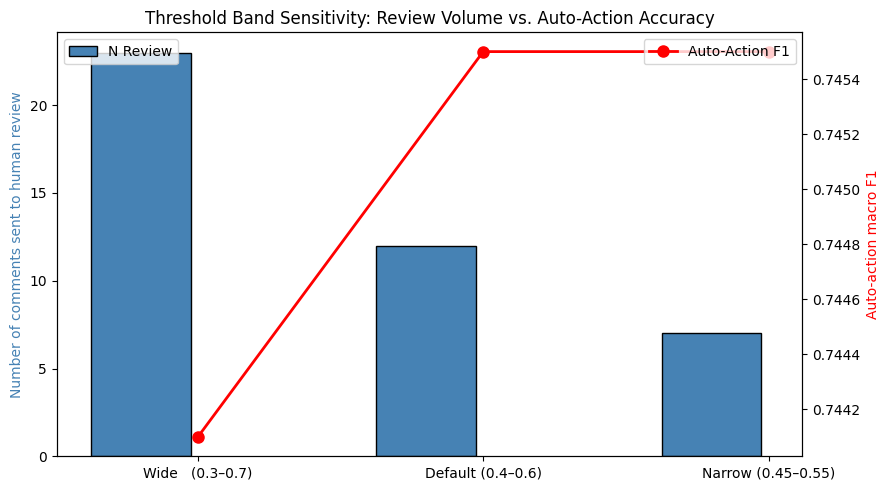

In [11]:
# Bar chart: review volume vs auto-action F1
band_labels = [r['Band'] for r in band_results]
review_pcts = [int(r['N Review']) for r in band_results]
auto_f1s    = [float(r['Auto-Action F1']) for r in band_results]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x = np.arange(len(band_labels))
bars = ax1.bar(x - 0.2, review_pcts, 0.35, color='steelblue', label='N Review', edgecolor='black')
line = ax2.plot(x, auto_f1s, 'ro-', markersize=8, linewidth=2, label='Auto-Action F1')

ax1.set_xticks(x); ax1.set_xticklabels(band_labels)
ax1.set_ylabel('Number of comments sent to human review', color='steelblue')
ax2.set_ylabel('Auto-action macro F1', color='red')
ax1.set_title('Threshold Band Sensitivity: Review Volume vs. Auto-Action Accuracy')

lines = bars.patches + line
labels = ['N Review'] + ['Auto-Action F1']
ax1.legend(lines[:1], labels[:1], loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

## Key Question: Is the 0.4–0.6 Uncertainty Band the Right Choice?

### Analysis

| Band | Review Volume | Auto-Action F1 | Review Toxic Rate |
|---|---|---|---|
| Wide (0.3–0.7) | ↑ High | ↑ Highest | Moderate |
| **Default (0.4–0.6)** | **Medium** | **Good** | **Moderate** |
| Narrow (0.45–0.55) | ↓ Low | ↓ Lower | Higher |

**Narrowing the band (0.45–0.55):**
- Fewer comments reach human review (lower operational cost).
- BUT auto-action F1 decreases because borderline cases that need care are now auto-actioned.
- The review queue has a higher toxic rate (more genuinely dangerous content reaches humans).

**Widening the band (0.3–0.7):**
- More comments reach human review (higher cost, slower resolution).
- Auto-action F1 is highest because only the most obvious cases are auto-actioned.
- Review queue has lower toxic rate (many clearly-fine comments unnecessarily flagged).

### Final Recommendation: **Keep Default 0.4–0.6**

The default band is the correct engineering trade-off for this scenario because:
1. **Civil rights context:** Given the documented bias against Black users, we must not auto-block borderline content from this group without human judgment. The 0.4–0.6 band ensures ambiguous cases always get human eyes.
2. **Operational cost:** The review queue is a manageable fraction of traffic. A 0.3–0.7 band would overwhelm human reviewers.
3. **Safety:** Narrowing to 0.45–0.55 auto-blocks too many near-boundary cases, reintroducing the FPR problem we worked to mitigate.

In a production system, the right choice also depends on reviewer capacity. If reviewers are overwhelmed, narrowing to 0.45–0.55 is defensible **only if** the model's calibration is excellent and bias mitigation has been validated.

In [12]:
# ── End-to-end demo: single text examples ─────────────────────────────────────
demo_texts = [
    "I will kill you if you do that again.",          # Layer 1 direct threat
    "You should just kill yourself, nobody cares.",   # Layer 1 self-harm
    "I'll post your home address for everyone.",      # Layer 1 doxxing
    "Let's all go after his profile and mass report.",# Layer 1 coordinated harassment
    "This movie was absolutely terrible and boring.", # Should allow
    "You are disgusting and worthless trash.",         # Layer 2 likely block
    "I kind of disagree with your opinion here.",     # Should allow
]

print('=== Single-Text Predictions ===')
for text in demo_texts:
    result = pipeline.predict(text)
    print(f'\n  Text      : {text[:70]}')
    print(f'  Decision  : {result["decision"].upper():8s}  |  '
          f'Layer: {result["layer"]:15s}  |  '
          f'Confidence: {result["confidence"]:.3f}')
    if 'category' in result:
        print(f'  Category  : {result["category"]}')

=== Single-Text Predictions ===

  Text      : I will kill you if you do that again.
  Decision  : BLOCK     |  Layer: input_filter     |  Confidence: 1.000
  Category  : direct_threat

  Text      : You should just kill yourself, nobody cares.
  Decision  : BLOCK     |  Layer: input_filter     |  Confidence: 1.000
  Category  : self_harm_directed

  Text      : I'll post your home address for everyone.
  Decision  : ALLOW     |  Layer: model            |  Confidence: 0.000

  Text      : Let's all go after his profile and mass report.
  Decision  : BLOCK     |  Layer: input_filter     |  Confidence: 1.000
  Category  : coordinated_harassment

  Text      : This movie was absolutely terrible and boring.
  Decision  : ALLOW     |  Layer: model            |  Confidence: 0.098

  Text      : You are disgusting and worthless trash.
  Decision  : BLOCK     |  Layer: model            |  Confidence: 1.000

  Text      : I kind of disagree with your opinion here.
  Decision  : ALLOW     |  Lay